### Test 1: Making a RA vs dec plot. 
##### Converted Ecliptic longitude $\lambda$ = 0-360$\degree$ while Ecliptic latitude $\beta$ = is 0$\degree$
##### Used Astropy's GeocentricTrueEcliptic with equinox set to 2025-09-23
##### Transformed the points to ICRS for the plot

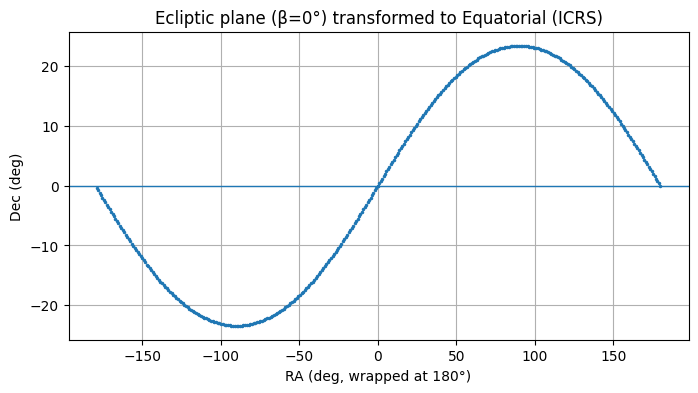

At ecliptic (λ,β)=(90°,0°):
  RA = 89.99379346894389 deg
  Dec= 23.439281212465453 deg


In [104]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, GeocentricTrueEcliptic, ICRS, GCRS, GeocentricMeanEcliptic, HeliocentricEclipticIAU76

# Build ecliptic coordinates: lambda 0 -> 360, beta = 0 
lam = np.linspace(0, 360, 361) * u.deg
beta = np.zeros_like(lam.value) * u.deg

# Picking fall equinox
#equinox = Time("2025-09-23", scale="utc")

ecl = SkyCoord(
    lon=lam,
    lat=beta,
    frame=GeocentricMeanEcliptic
)
 
# Convert to equatorial (ICRS)
eq = ecl.transform_to(ICRS)

#eq = ecl.transform_to(
#    TrueEclipticGeocentric(equinox=equinox)
#)

#ecl_back = eq.transform_to(
#    GeocentricTrueEcliptic(equinox=equinox)
#)




ra = eq.ra.deg   # wrap for nicer plotting (-180 - 180)
raW = eq.ra.wrap_at(180 * u.deg).deg   # wrap for nicer plotting (-180 - 180)
dec = eq.dec.deg

# Plot RA vs Dec 
plt.figure(figsize=(8, 4))
plt.plot(raW, dec, ".", ms=3)
plt.axhline(0, lw=1)
plt.xlabel("RA (deg, wrapped at 180°)")
plt.ylabel("Dec (deg)")
plt.title("Ecliptic plane (β=0°) transformed to Equatorial (ICRS)")
plt.grid(True)
plt.show()

# Check at lambda = 90 
idx_90 = np.argmin(np.abs(lam.to_value(u.deg) - 90.0))
print("At ecliptic (λ,β)=(90°,0°):")
print("  RA =", eq.ra[idx_90].deg, "deg")
print("  Dec=", eq.dec[idx_90].deg, "deg")


### Test 2: Inverse Transformation from Equatorial --> Ecliptic
##### Taking the same RA/dec from Test 1 and going back to ecliptic coords with GeocentricTrueEcliptic

In [69]:
equinox = Time("2025-09-23", scale="utc")

# Take RA/Dec and go back to ecliptic
eq = SkyCoord(
    ra=ra * u.deg,
    dec=dec * u.deg,
    frame="icrs",
)

ecl_back = eq.transform_to(
    GeocentricMeanEcliptic 
)

lam_back = ecl_back.lon.deg
beta_back = ecl_back.lat.deg

print("max |beta| (deg):", np.max(np.abs(beta_back))) # v close to 0
print("max |Δlambda| (deg):", np.mean(np.abs((lam_back - lam.to_value(u.deg)) % 360)))

print(np.min(ra), np.max(ra))
print(np.min(lam.to_value(u.deg)), np.max(lam.to_value(u.deg)))
print(np.min(lam_back), np.max(lam_back))


max |beta| (deg): 4.333505753494043e-14
max |Δlambda| (deg): 178.50415512465372
0.0009559081557172468 359.08355006487994
0.0 360.0
0.9999999999905808 359.9999999999896


In [70]:
ra[0]

np.float64(0.0009559081557172468)

#### Test 3: Sun's motion over a year
##### Calc. Sun's apparent position using get_sun() for 365 days starting from 2025-09-23
##### Converted the Sun's position to RA/dec (ICRS) 
##### Overplotted the Sun's position onto the ecliptic curve from Test 1

In [64]:
ecl.icrs

<SkyCoord (ICRS): (ra, dec) in deg
    [(9.55908156e-04,  4.20806500e-04), (9.18361552e-01,  3.98141188e-01),
     (1.83585543e+00,  7.95759375e-01), (2.75352590e+00,  1.19317340e+00),
     (3.67146124e+00,  1.59028126e+00), (4.58974953e+00,  1.98698092e+00),
     (5.50847864e+00,  2.38317030e+00), (6.42773614e+00,  2.77874724e+00),
     (7.34760926e+00,  3.17360951e+00), (8.26818483e+00,  3.56765480e+00),
     (9.18954923e+00,  3.96078068e+00), (1.01117883e+01,  4.35288465e+00),
     (1.10349873e+01,  4.74386404e+00), (1.19592308e+01,  5.13361608e+00),
     (1.28846029e+01,  5.52203788e+00), (1.38111865e+01,  5.90902636e+00),
     (1.47390640e+01,  6.29447832e+00), (1.56683168e+01,  6.67829039e+00),
     (1.65990252e+01,  7.06035907e+00), (1.75312688e+01,  7.44058064e+00),
     (1.84651257e+01,  7.81885126e+00), (1.94006729e+01,  8.19506691e+00),
     (2.03379864e+01,  8.56912339e+00), (2.12771405e+01,  8.94091635e+00),
     (2.22182084e+01,  9.31034129e+00), (2.31612614e+01,  9.67729

In [64]:
ecl.icrs

<SkyCoord (ICRS): (ra, dec) in deg
    [(9.55908156e-04,  4.20806500e-04), (9.18361552e-01,  3.98141188e-01),
     (1.83585543e+00,  7.95759375e-01), (2.75352590e+00,  1.19317340e+00),
     (3.67146124e+00,  1.59028126e+00), (4.58974953e+00,  1.98698092e+00),
     (5.50847864e+00,  2.38317030e+00), (6.42773614e+00,  2.77874724e+00),
     (7.34760926e+00,  3.17360951e+00), (8.26818483e+00,  3.56765480e+00),
     (9.18954923e+00,  3.96078068e+00), (1.01117883e+01,  4.35288465e+00),
     (1.10349873e+01,  4.74386404e+00), (1.19592308e+01,  5.13361608e+00),
     (1.28846029e+01,  5.52203788e+00), (1.38111865e+01,  5.90902636e+00),
     (1.47390640e+01,  6.29447832e+00), (1.56683168e+01,  6.67829039e+00),
     (1.65990252e+01,  7.06035907e+00), (1.75312688e+01,  7.44058064e+00),
     (1.84651257e+01,  7.81885126e+00), (1.94006729e+01,  8.19506691e+00),
     (2.03379864e+01,  8.56912339e+00), (2.12771405e+01,  8.94091635e+00),
     (2.22182084e+01,  9.31034129e+00), (2.31612614e+01,  9.67729

2025-09-23 00:00:00.000 2026-09-22 00:00:00.000


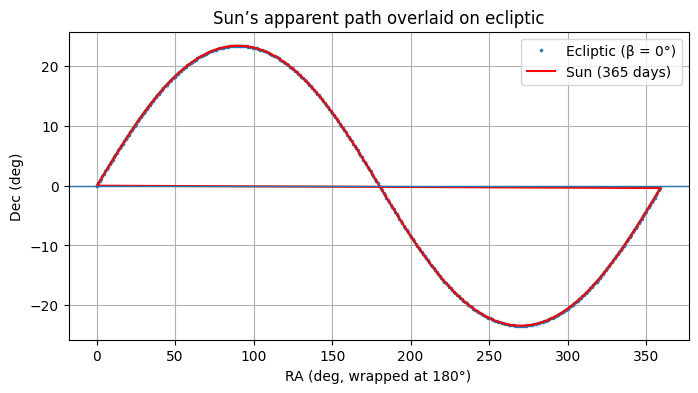

In [74]:
from astropy.coordinates import get_sun

# 365 days starting Sep 23, 2025 
t0 = Time("2025-09-23", scale="utc")
times = t0 + np.arange(365) * u.day
print(np.min(times), np.max(times))

# Sun position in RA/Dec 
#sun = get_sun(times).transform_to(ICRS())
sun = get_sun(times) 

#sun_ra = sun.ra.wrap_at(180 * u.deg).deg
sun_ra = sun.ra.deg
sun_dec = sun.dec.deg

# Plot: ecliptic curve + Sun track 
plt.figure(figsize=(8, 4))

# ecliptic line from test 1
plt.plot(ra, dec, ".", ms=3, label="Ecliptic (β = 0°)")

# Sun 
plt.plot(sun_ra, sun_dec, "r-", lw=1.5, label="Sun (365 days)")

plt.axhline(0, lw=1)
plt.xlabel("RA (deg, wrapped at 180°)")
plt.ylabel("Dec (deg)")
plt.legend()
plt.grid(True)
plt.title("Sun’s apparent path overlaid on ecliptic")
plt.show()


In [75]:
sun_ra


array([1.79881947e+02, 1.80780332e+02, 1.81679265e+02, 1.82578820e+02,
       1.83479076e+02, 1.84380108e+02, 1.85281998e+02, 1.86184824e+02,
       1.87088670e+02, 1.87993619e+02, 1.88899757e+02, 1.89807174e+02,
       1.90715960e+02, 1.91626212e+02, 1.92538028e+02, 1.93451510e+02,
       1.94366758e+02, 1.95283875e+02, 1.96202956e+02, 1.97124095e+02,
       1.98047378e+02, 1.98972886e+02, 1.99900697e+02, 2.00830881e+02,
       2.01763506e+02, 2.02698635e+02, 2.03636330e+02, 2.04576648e+02,
       2.05519645e+02, 2.06465375e+02, 2.07413889e+02, 2.08365237e+02,
       2.09319469e+02, 2.10276631e+02, 2.11236769e+02, 2.12199928e+02,
       2.13166151e+02, 2.14135482e+02, 2.15107963e+02, 2.16083636e+02,
       2.17062543e+02, 2.18044730e+02, 2.19030244e+02, 2.20019132e+02,
       2.21011444e+02, 2.22007228e+02, 2.23006529e+02, 2.24009384e+02,
       2.25015824e+02, 2.26025869e+02, 2.27039532e+02, 2.28056815e+02,
       2.29077715e+02, 2.30102220e+02, 2.31130312e+02, 2.32161967e+02,
      

#### Test 4: Sun and anti-Sun position on Fall equinox (or well more like Sept. 23rd)
##### Calc. Sun's position on 23rd Sept.
##### Convert the Sun to ecliptic coords.
##### Defined anti-Sun position by adding 180$\degree$ in ecliptic longitude
##### Transformed both back to RA/dec to plot on ecliptic curve

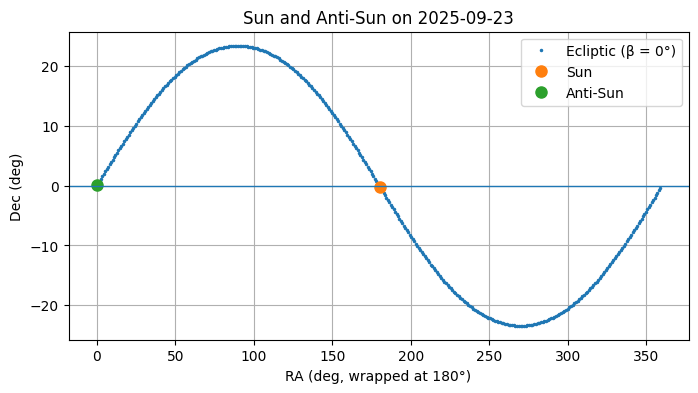

Sun  (λ,β) = 180.72108041599012 -7.755749233650018e-05
Anti (λ,β) = 0.7210804159901159 7.755749233650018e-05


In [127]:
# Sept. 23rd Equinox
t = Time("2025-09-23 12:00:00", scale="utc")
ecl_frame = GeocentricTrueEcliptic(equinox=t)
#ecl_frame = GeocentricMeanEcliptic(equinox=t)

# Sun converted to ecliptic lon/lat
sun_icrs = get_sun(t).transform_to(ICRS())
sun_gcrs = get_sun(t)
sun_ecl  = sun_gcrs.transform_to(ecl_frame) #swappped icrs to gcrs

# Anti-sun in ecliptic: lon+180, lat doesn't count since 0 anyway
anti_ecl = SkyCoord(lon=sun_ecl.lon + 180*u.deg, lat=-sun_ecl.lat, frame=ecl_frame)

# Convert both back to GCRS now for plotting on the RA/Dec ecliptic curve
sun_plot  = sun_ecl.transform_to(GCRS()) # swap ICRS to GCRS
anti_plot = anti_ecl.transform_to(GCRS()) # swap ICRS to GCRS


#sun_ra  = sun_plot.ra.wrap_at(180*u.deg).deg
#using without wrap
sun_ra = sun_plot.ra.deg

sun_dec = sun_plot.dec.deg
#using without wrap
#anti_ra  = anti_plot.ra.wrap_at(180*u.deg).deg
anti_ra = anti_plot.ra.deg
anti_dec = anti_plot.dec.deg

plt.figure(figsize=(8,4))
plt.plot(ra, dec, ".", ms=3, label="Ecliptic (β = 0°)")
plt.plot(sun_ra,  sun_dec,  "o", ms=8, label="Sun")
plt.plot(anti_ra, anti_dec, "o", ms=8, label="Anti-Sun")
plt.axhline(0, lw=1)
plt.xlabel("RA (deg, wrapped at 180°)")
plt.ylabel("Dec (deg)")
plt.legend()
plt.grid(True)
plt.title("Sun and Anti-Sun on 2025-09-23")
plt.show()

# Checking the ecliptic coords:
print("Sun  (λ,β) =", sun_ecl.lon.deg, sun_ecl.lat.deg)
print("Anti (λ,β) =", (sun_ecl.lon + 180*u.deg).wrap_at(360*u.deg).deg, (-sun_ecl.lat).deg)


In [128]:
sun_gcrs

<SkyCoord (GCRS: obstime=2025-09-23 12:00:00.000, obsgeoloc=(0., 0., 0.) m, obsgeovel=(0., 0., 0.) m / s): (ra, dec, distance) in (deg, deg, AU)
    (180.33107541, -0.14327459, 1.00341956)>

In [129]:
sun_icrs

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, AU)
    (233.38830547, -17.90645549, 0.00668336)>

In [130]:
sun_ecl

<SkyCoord (GeocentricTrueEcliptic: equinox=2025-09-23 12:00:00.000, obstime=2025-09-23 12:00:00.000): (lon, lat, distance) in (deg, deg, AU)
    (180.72108042, -7.75574923e-05, 1.00341956)>

In [131]:
sun_icrs2

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, AU)
    (233.38830547, -17.90645549, 0.00668336)>